In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")
import pandas as pd
import numpy as np
from cfe.data import FateAnnData
from cfe.metric.metric_correlation_v2 import calculate_correlation
from cfe.metric.metric_position_predict_v2 import calculate_position_predict
from cfe.metric.metric_featureimp_v2 import (
    calculate_overall_feature_importance,
    calculate_featureimp_cor,
    calculate_featureimp_enrichment,
    fi_ranger_rf_tiny
)
from cfe.metric.cluster_metric_v2 import calculate_mapping_branches, calculate_mapping_milestones,calculate_mapping
from cfe.metric._topology_metric.metric_him import calculate_him
from cfe.metric.topology_metric import calc_isomorphic, calculate_edge_flip

[2025年04月26日 15时48分43秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"

sc.pp.subsample(fadata, n_obs=2000)

fadata

[2025年04月26日 15时48分44秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                
                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      


AnnData object with n_obs × n_vars = 2000 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network)

                        DEBUG    FateAnnData add_trajectory                                                        


[2025年04月26日 15时48分49秒] DEBUG    plot_trajectory                                                             
[2025年04月26日 15时48分52秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年04月26日 15时48分53秒] DEBUG    add waypoints shape is (210, 2000), finished!                               


<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

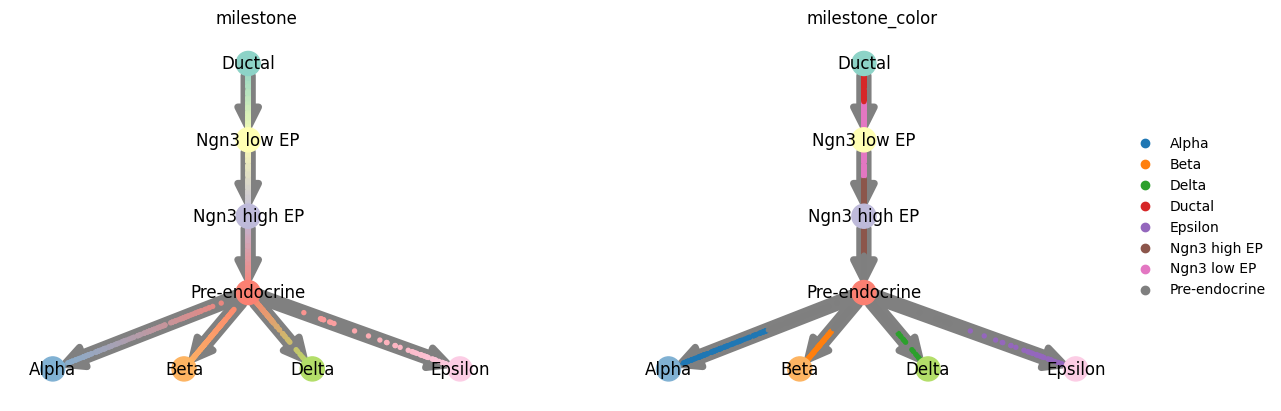

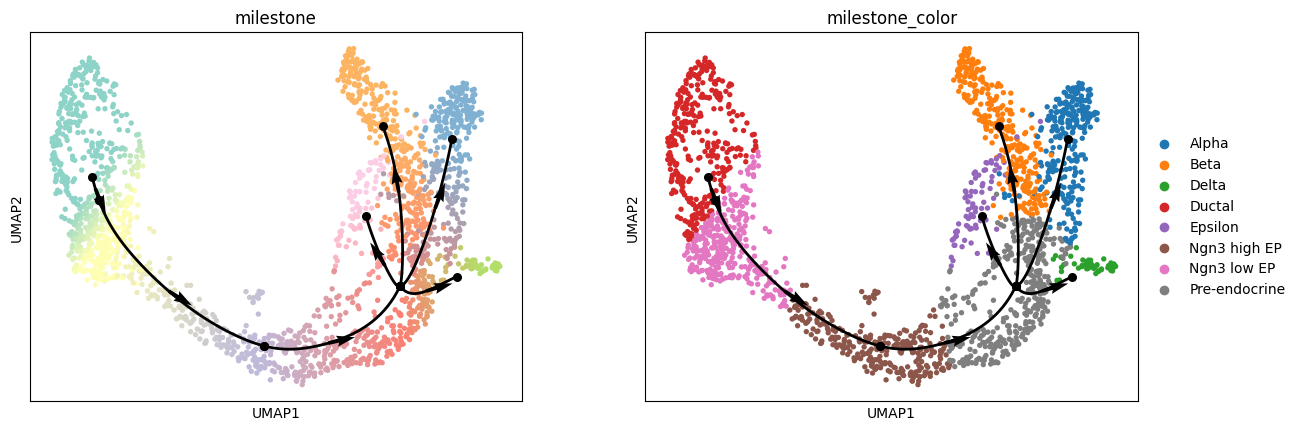

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年04月26日 15时49分05秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x732f9014bb50> from                       
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_comp1.py                   
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x73303ac2bd30>                                                                   
[2025年04月26日 15时49分06秒] DEBUG    FateAnnData add_trajectory                                                  
                        DEBUG    plot_trajectory                                                                   
[2025年04月26日 15时49分09秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                

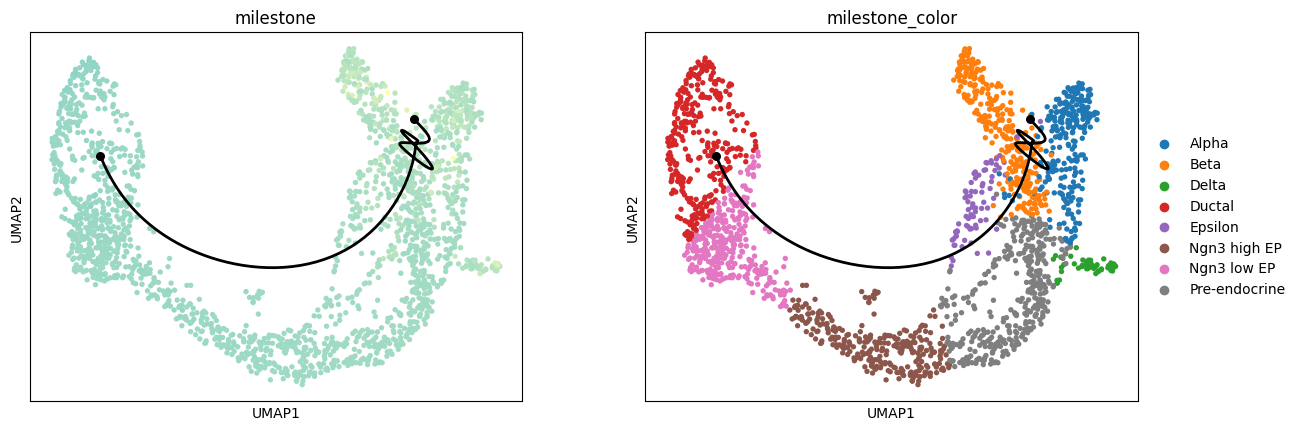

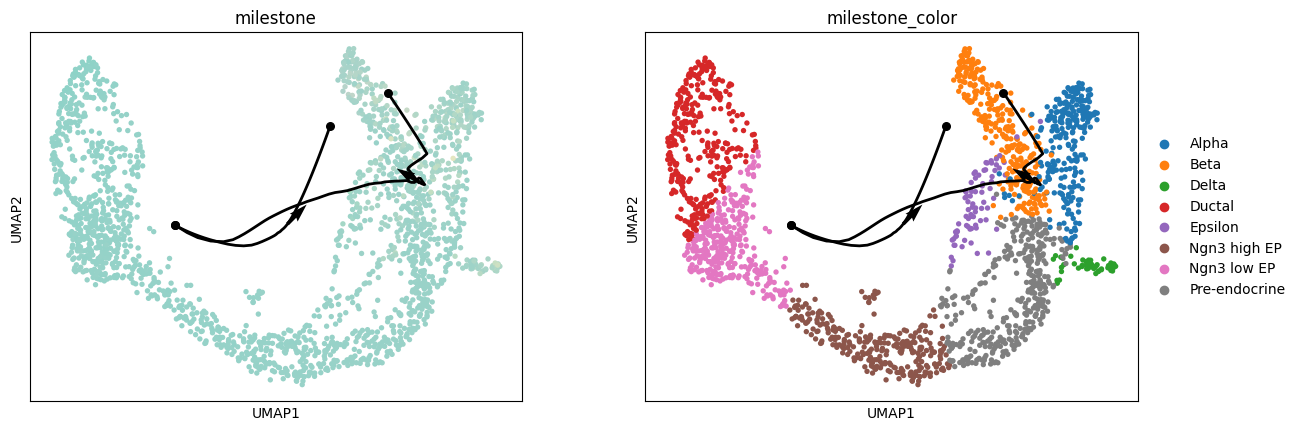

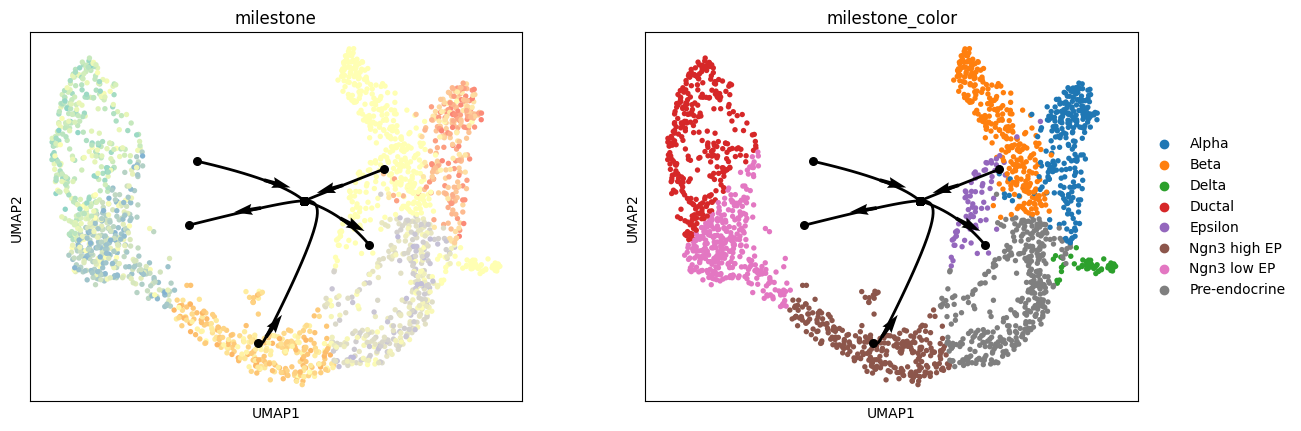

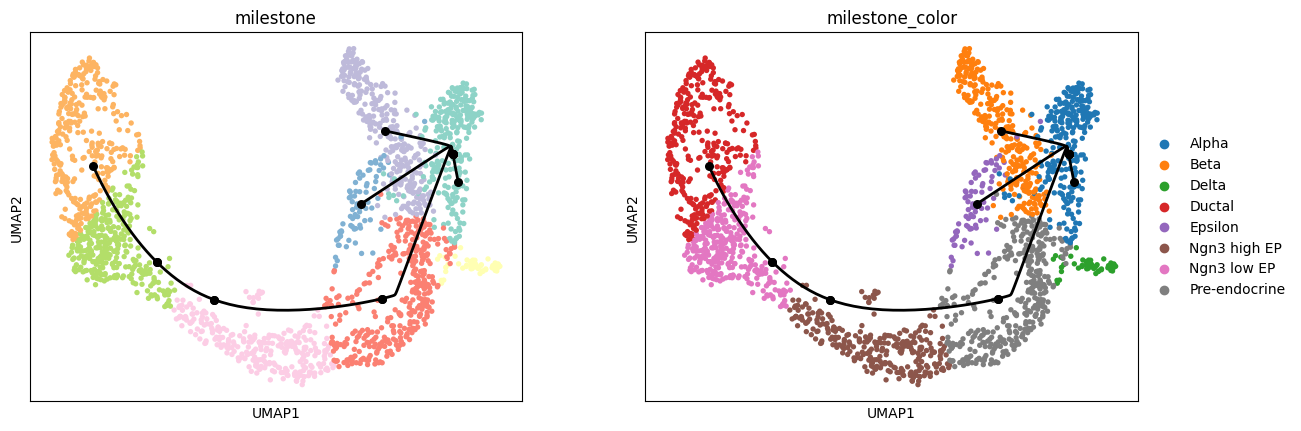

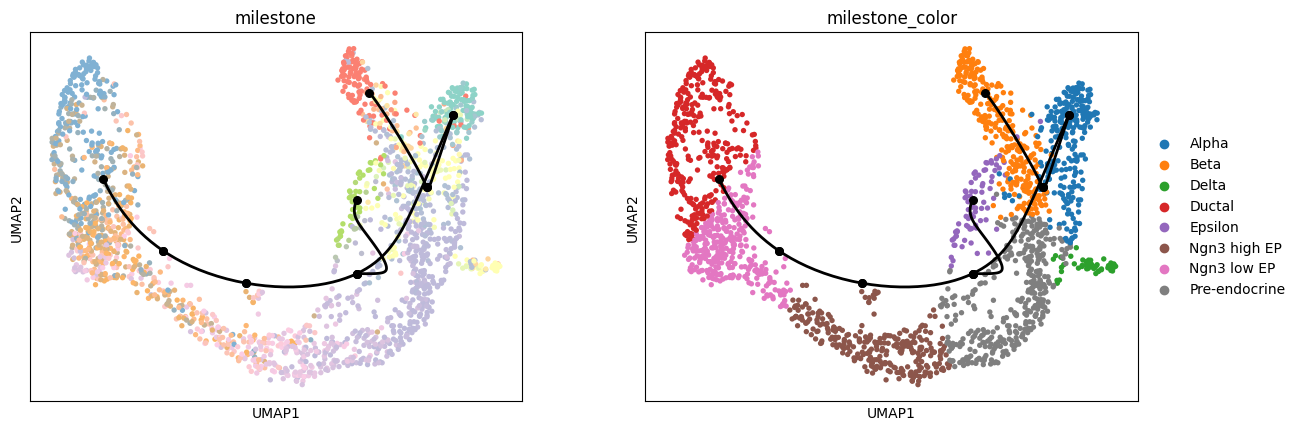

In [5]:
# TODO: PAGA need to be optimized, disconnected graph
prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["comp1", "state_comp","paga","cluster_mst","projection_mst"]
#method_name_list = ["comp1", "angle", "state_comp","paga","cluster_mst","projection_mst","graph_mst"]
# method_name_list = ["comp1", "state_comp","paga","cluster_mst","projection_mst","graph_mst"]
#method_name_list = ["comp1", "state_comp"]

for method_name in method_name_list:
        method = cfe.method.FateMethod(method_name=method_name)
        method.infer_trajectory(fadata)
        cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)